## Load ONE curve (sanity check)

In [1]:
import numpy as np

data = np.load("/home/jovyan/work/MST/results/ODELIA/DinoV2ClassifierSlice_Final/evaluation/negative/negative_curves/attention_rollout/02F4A1FB_left_curve.npy", allow_pickle=True).item()

percentages = np.array(data["percentages"])
confidences = np.array(data["confidences"])

print(percentages.shape, confidences.shape)


(21,) (21,)


## Load ALL curves and stack them

## Attention Rollout

In [2]:
import numpy as np
from pathlib import Path

curve_dir = Path("/home/jovyan/work/MST/results/ODELIA/DinoV2ClassifierSlice_Final/evaluation/negative/negative_curves/attention_rollout") 
curves_confidence = []
cureves_normalized = []
percentages = None

for f in curve_dir.glob("*.npy"):
    data = np.load(f, allow_pickle=True).item()
    curves_confidence.append(data["confidences"])
    cureves_normalized.append(data["normalized_confidences"])
    if percentages is None:
        percentages = data["percentages"]

curves_confidence = np.array(curves_confidence)
cureves_normalized = np.array(cureves_normalized)

print("curves_confidence shape:", curves_confidence.shape)
print("cureves_normalized shape:", cureves_normalized.shape)
print("percentages shape:", np.array(percentages).shape)

mean_conf = curves_confidence.mean(axis=0)
mean_norm = cureves_normalized.mean(axis=0)



curves_confidence shape: (116, 21)
cureves_normalized shape: (116, 21)
percentages shape: (21,)


In [5]:
curves_confidence.shape

(116, 21)

In [8]:
curves_confidence

array([[0.99927992, 0.99926394, 0.99922824, ..., 0.84036362, 0.09886751,
        0.16241969],
       [0.99902809, 0.99909031, 0.99911731, ..., 0.81817585, 0.98239052,
        0.83058858],
       [0.63624442, 0.62310779, 0.79642761, ..., 0.88223398, 0.97405368,
        0.16241969],
       ...,
       [0.99664682, 0.99666494, 0.99581617, ..., 0.11402804, 0.02356762,
        0.16241969],
       [0.93424588, 0.87240005, 0.86308604, ..., 0.08919406, 0.15950124,
        0.83058858],
       [0.96418965, 0.98638541, 0.98597044, ..., 0.9296118 , 0.72938693,
        0.16241969]])

In [9]:
cureves_normalized

array([[0.9997648 , 0.99974704, 0.99970734, ..., 0.8233135 , 0.        ,
        0.07056459],
       [0.999355  , 0.9996989 , 0.99984807, ..., 0.        , 0.907419  ,
        0.06859037],
       [0.56817317, 0.55242074, 0.7602522 , ..., 0.8631444 , 0.9732473 ,
        0.        ],
       ...,
       [0.997407  , 0.9974256 , 0.9965556 , ..., 0.09272201, 0.        ,
        0.1423235 ],
       [1.        , 0.9320398 , 0.92180496, ..., 0.07140209, 0.14866018,
        0.8860946 ],
       [0.9577563 , 0.9842703 , 0.9837746 , ..., 0.9164513 , 0.67727214,
        0.        ]], dtype=float32)

In [7]:
mean_conf

array([0.92960393, 0.92558836, 0.92473404, 0.91821952, 0.91145961,
       0.88742639, 0.85480936, 0.81490933, 0.76135336, 0.72674159,
       0.7000629 , 0.67366359, 0.64634525, 0.62114201, 0.60654141,
       0.58730537, 0.55180022, 0.55362275, 0.49202259, 0.4551621 ,
       0.31726443])

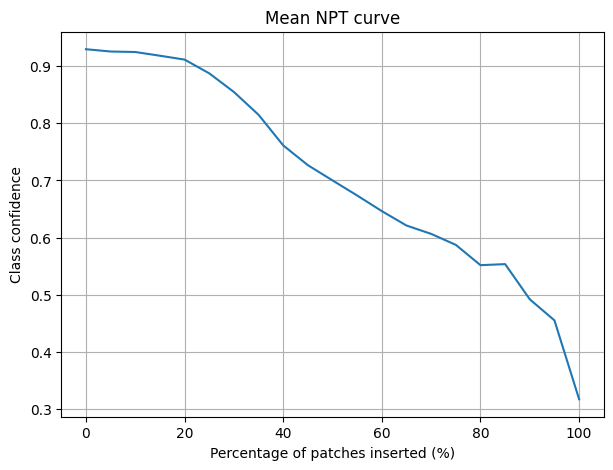

In [3]:
import matplotlib.pyplot as plt

x_percent = np.array(percentages) * 100

plt.figure(figsize=(7, 5))
plt.plot(x_percent, mean_conf)
plt.xlabel("Percentage of patches inserted (%)")
# plt.xticks(
#     ticks=x_percent,
#     labels=[f"{int(p)}%" for p in x_percent]
# )
plt.ylabel("Class confidence")
plt.title("Mean NPT curve")
plt.grid(True)
plt.show()


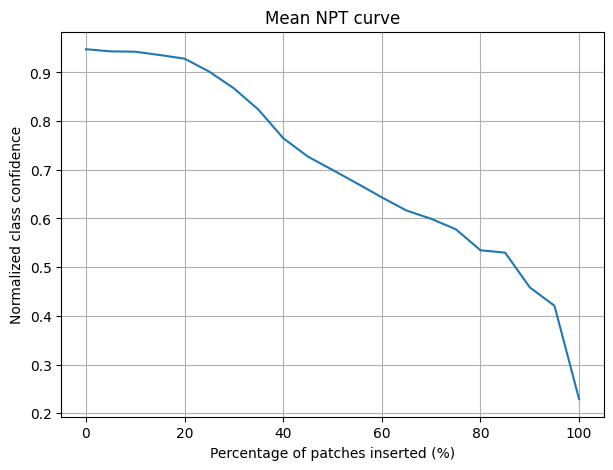

In [4]:
import matplotlib.pyplot as plt

x_percent = np.array(percentages) * 100

plt.figure(figsize=(7, 5))
plt.plot(x_percent, mean_norm)
plt.xlabel("Percentage of patches inserted (%)")
# plt.xticks(
#     ticks=x_percent,
#     labels=[f"{int(p)}%" for p in x_percent]
# )
plt.ylabel("Normalized class confidence")
plt.title("Mean NPT curve")
plt.grid(True)
plt.show()
